# Chapter 2: Tensors and Differential Forms

**Source Span.** `Foundations of Differentiable Manifolds and Lie Groups.pdf` printed pages `54-81`, covering tensor and exterior algebras, tensor fields and differential forms, the Lie derivative, and differential ideals.

**Chapter Goal.** Turn multilinear algebra into geometric fields. Tensors measure vectors and covectors in coordinate-free combinations. Exterior forms keep the alternating part that controls oriented volume and integration. The Lie derivative differentiates tensors along a flow. Differential ideals encode distributions and give the forms version of Frobenius.

This notebook replaces the bootstrap graph with a source-specific route: tensor slots and contraction, wedge signs and determinant scaling, form fields and exterior derivative, Lie derivative through a flow, and the ideal test `alpha wedge d alpha`. The examples are original and small enough to audit directly.


In [1]:
from pathlib import Path
import json, math, sys
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import sympy as sp
import plotly.graph_objects as go
BOOK_ROOT=None
for candidate in [Path.cwd(), *Path.cwd().parents]:
    if (candidate/'AGENTS.md').exists() and (candidate/'source_map.json').exists(): BOOK_ROOT=candidate; break
if BOOK_ROOT is None: raise RuntimeError('book root not found')
if str(BOOK_ROOT) not in sys.path: sys.path.insert(0,str(BOOK_ROOT))
from utils.artifacts import assert_artifacts, chapter_artifact_root, display_artifact, save_csv, save_json, save_matplotlib, save_plotly_html
UNIT_KEY='chapter-02-tensors-and-differential-forms'
ARTIFACT_ROOT=chapter_artifact_root(UNIT_KEY, BOOK_ROOT)
FIGURES,HTML,CHECKS,TABLES=(ARTIFACT_ROOT/name for name in ['figures','html','checks','tables'])
TRACKED_ARTIFACTS=[]
print(f'Book root: {BOOK_ROOT}')


Book root: D:\Geometry\Foundations-of-Differentiable-Manifolds-and-Lie-Groups


## Visual Storyboard

1. **Tensor slot diagram.** A bilinear form is shown as a two-input machine, with matrix evaluation and contraction checks.
2. **Exterior algebra sign table.** Alternating products vanish on repeated covectors and change sign under swaps; top forms scale by determinants.
3. **Lie derivative flow lab.** A tensor field is pulled along a flow, and the derivative at time zero is compared with Cartan's formula for a one-form.
4. **Differential ideal and Frobenius.** The ideal generated by one-forms is tested by exterior derivative closure. The contact form `alpha=dz-y dx` fails because `alpha wedge d alpha` is nonzero, while `dz` passes.
5. **Dependency graph.** Tensor algebra, exterior algebra, fields, Lie derivative, and differential ideals are connected to Chapter 1's distributions.

## Library Routing

| Concept | Representation | Library | Why it fits | Check |
| --- | --- | --- | --- | --- |
| Tensor/contraction | Matrix and slot diagram | Matplotlib + SymPy | Tensors are multilinear maps with slots | bilinear evaluation equals matrix formula |
| Exterior algebra | Wedge sign table | SymPy + Matplotlib | Alternation is exact sign algebra | antisymmetry and determinant scaling |
| Lie derivative | Pullback along a flow | Plotly + SymPy | Flow differentiation is visual and symbolic | finite difference matches formula |
| Differential ideals | Pfaffian plane fields | Matplotlib + SymPy | Frobenius is ideal closure under `d` | `alpha wedge d alpha` obstruction |


## Tensor Slots And Exterior Signs

A tensor is a multilinear rule with slots. In coordinates, a bilinear form can be evaluated by a matrix, but the coordinate-free point is that each slot receives a vector and the output is linear in each argument. Exterior algebra extracts the alternating part. Repeating an input kills an alternating form, and swapping inputs changes a sign. The table and matrix checks below make those rules explicit.


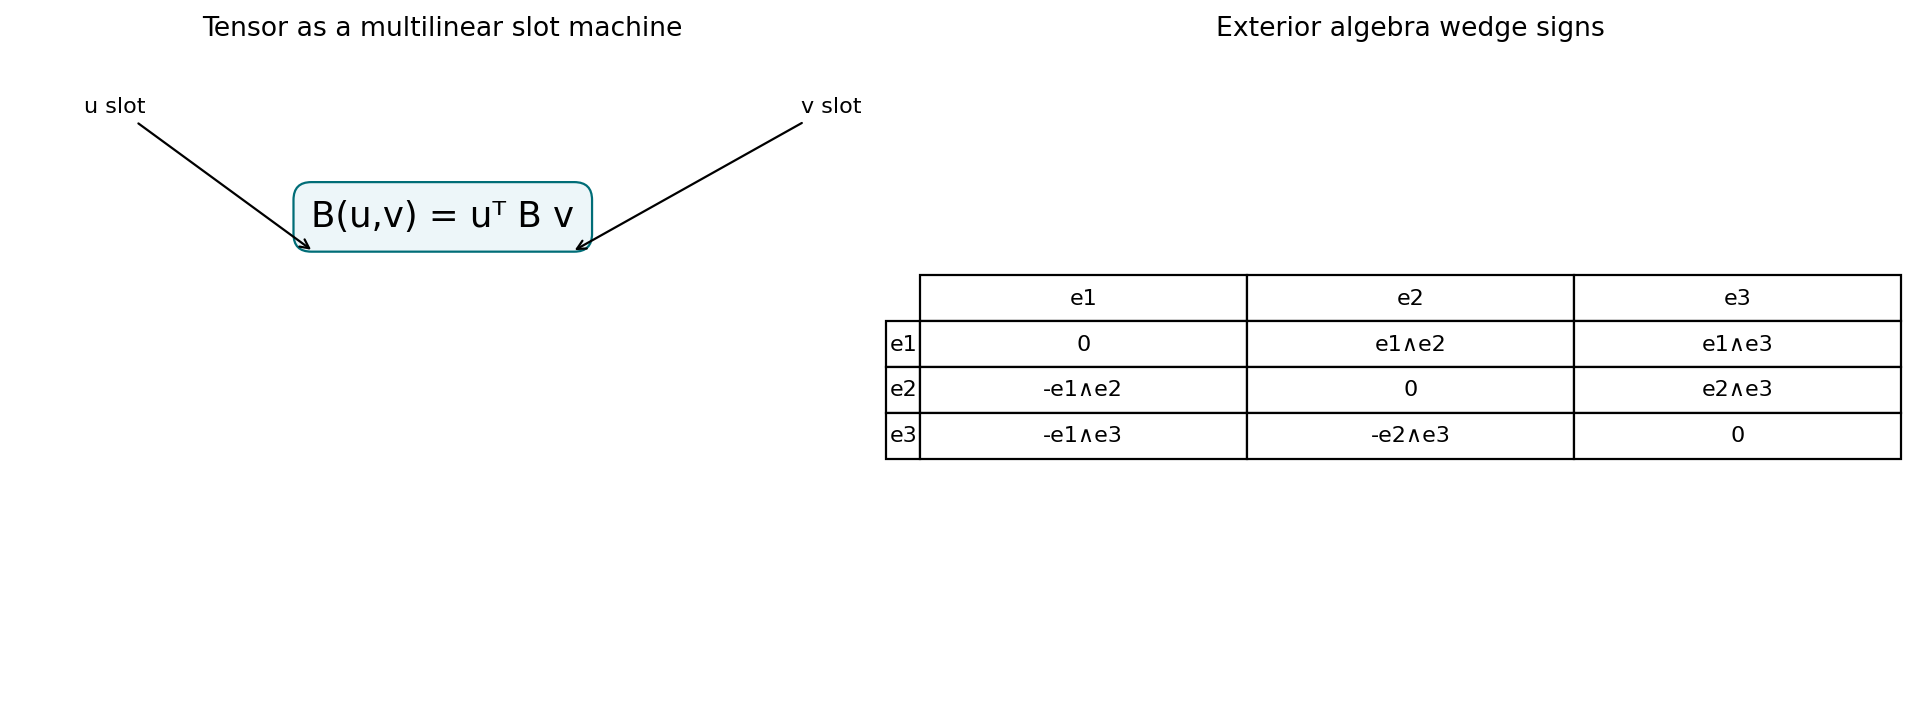

{'slot_check': True, 'det_check': True}

In [2]:
u1,u2,v1,v2=sp.symbols('u1 u2 v1 v2')
B=sp.Matrix([[2,1],[-1,3]])
u=sp.Matrix([u1,u2]); v=sp.Matrix([v1,v2])
bilinear=sp.expand((u.T*B*v)[0])
slot_check=sp.simplify(bilinear - (2*u1*v1 + u1*v2 - u2*v1 + 3*u2*v2))==0
wedge_table=np.array([['0','e1∧e2','e1∧e3'],['-e1∧e2','0','e2∧e3'],['-e1∧e3','-e2∧e3','0']], dtype=object)
fig,axes=plt.subplots(1,2,figsize=(12,4.5))
axes[0].axis('off')
axes[0].text(.5,.72,'B(u,v) = uᵀ B v',ha='center',fontsize=16,bbox=dict(boxstyle='round,pad=.5',fc='#edf6f9',ec='#006d77'))
axes[0].annotate('u slot', xy=(.35,.68), xytext=(.08,.9), arrowprops=dict(arrowstyle='->'))
axes[0].annotate('v slot', xy=(.65,.68), xytext=(.92,.9), arrowprops=dict(arrowstyle='->'))
axes[0].set_title('Tensor as a multilinear slot machine')
axes[1].axis('off')
table=axes[1].table(cellText=wedge_table,rowLabels=['e1','e2','e3'],colLabels=['e1','e2','e3'],loc='center',cellLoc='center')
table.auto_set_font_size(False); table.set_fontsize(10); table.scale(1.15,1.5)
axes[1].set_title('Exterior algebra wedge signs')
fig.tight_layout()
tensor_path=save_matplotlib(fig, FIGURES/'tensor-slots-and-wedge-signs.png')
plt.close(fig)
a,b,c,d=sp.symbols('a b c d')
det_check=sp.simplify((a*d-b*c)-sp.Matrix([[a,b],[c,d]]).det())==0
tensor_json=save_json({'bilinear_expression':str(bilinear),'slot_check':bool(slot_check),'wedge_antisymmetry':'e_i wedge e_j = - e_j wedge e_i','top_form_matches_determinant':bool(det_check)}, CHECKS/'tensor-slots-and-wedge-signs.json')
TRACKED_ARTIFACTS.extend([tensor_path,tensor_json])
display_artifact(tensor_path,width=840)
{'slot_check': slot_check, 'det_check': det_check}


## Lie Derivative Along A Flow

The Lie derivative measures the infinitesimal change of a tensor field as it is transported by a vector-field flow. For functions this is directional derivative. For forms and tensors, pullback along the flow is the clean definition. The example uses the vector field `X = d/dx` and the one-form `omega = x dy`. Flowing by time `t` sends `x` to `x+t`, so the pulled-back form changes by `t dy`; the derivative at `t=0` is `dy`. Cartan's formula gives the same result.


In [3]:
x,y,t=sp.symbols('x y t')
# omega = x dy; flow of X=d/dx is Phi_t(x,y)=(x+t,y).
pullback_coeff_dy = x + t
finite_lie_coeff = sp.diff(pullback_coeff_dy, t).subs(t,0)
# Cartan formula L_X omega = i_X d omega + d(i_X omega). d omega = dx wedge dy; i_X = dy.
cartan_coeff_dy = 1
lie_check = sp.simplify(finite_lie_coeff - cartan_coeff_dy)==0
xs=np.linspace(-1,1,25); ys=np.linspace(-1,1,25)
Xg,Yg=np.meshgrid(xs,ys); coeff=Xg
fig=go.Figure()
fig.add_trace(go.Cone(x=Xg.ravel(),y=Yg.ravel(),z=np.zeros(Xg.size),u=np.zeros(Xg.size),v=coeff.ravel(),w=np.zeros(Xg.size),sizemode='absolute',sizeref=.18,colorscale='Blues',showscale=False,name='omega=x dy'))
fig.update_layout(title='One-form omega=x dy before flow; Lie derivative along d/dx is dy',width=760,height=560,scene=dict(zaxis=dict(visible=False),aspectmode='data'))
lie_html=save_plotly_html(fig, HTML/'lie-derivative-flow-pullback.html')
lie_json=save_json({'finite_difference_lie_coeff_dy':str(finite_lie_coeff),'cartan_formula_coeff_dy':cartan_coeff_dy,'matches':bool(lie_check)}, CHECKS/'lie-derivative-flow-pullback.json')
TRACKED_ARTIFACTS.extend([lie_html,lie_json])
display_artifact(lie_html,width=800,height=560)
{'lie_check': lie_check}


D:\Geometry\.venv\Lib\site-packages\IPython\core\display.py:447: UserWarning: Consider using IPython.display.IFrame instead
  warnings.warn("Consider using IPython.display.IFrame instead")


{'lie_check': True}

## Differential Ideals And Frobenius In Form Language

A differential ideal is an ideal of forms closed under exterior derivative. Warner uses this language to restate Frobenius: a distribution described as the common kernel of one-forms is integrable when the ideal generated by those forms is closed under `d`. For a single one-form in three dimensions, the obstruction is visible in `alpha wedge d alpha`. If this three-form is nonzero, the plane field twists too much to be tangent to surfaces.


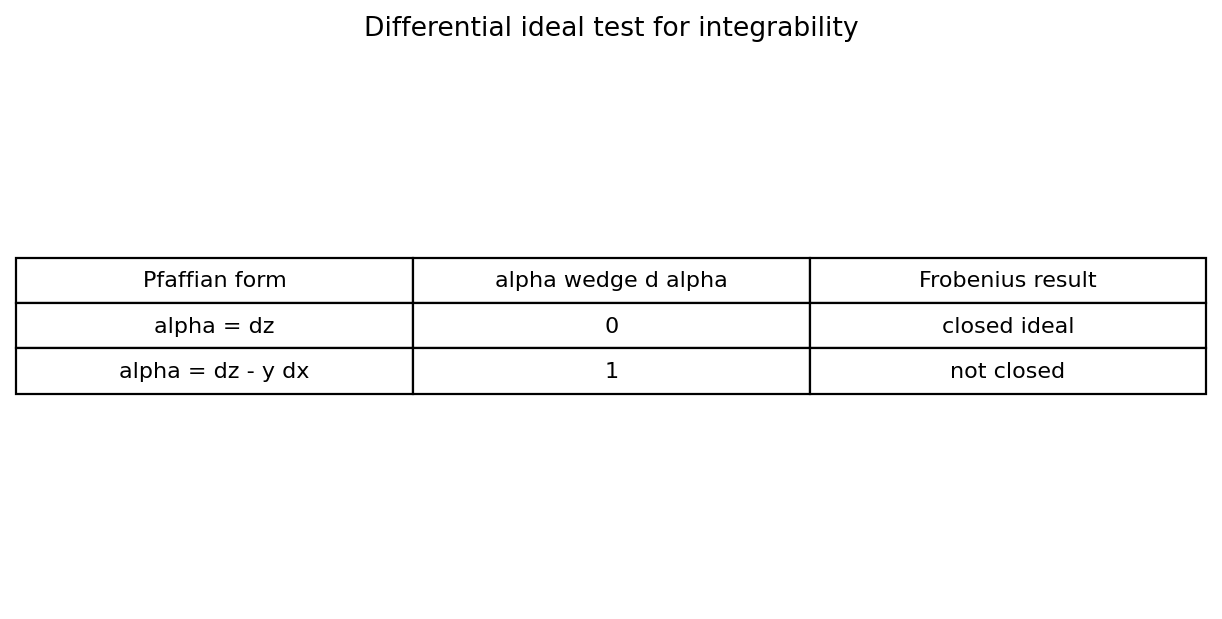

[['alpha = dz', '0', 'closed ideal'], ['alpha = dz - y dx', '1', 'not closed']]

In [4]:
x,y,z=sp.symbols('x y z')
# Represent one-forms by coefficient triples and compute alpha wedge d alpha coefficient.
def alpha_wedge_dalpha_coeff(A):
    P,Q,R=A
    # d alpha coefficients: dxdy = Q_x - P_y, dxdz = R_x - P_z, dydz = R_y - Q_z
    c_xy=sp.diff(Q,x)-sp.diff(P,y)
    c_xz=sp.diff(R,x)-sp.diff(P,z)
    c_yz=sp.diff(R,y)-sp.diff(Q,z)
    # alpha wedge d alpha coefficient for dx dy dz: P*c_yz - Q*c_xz + R*c_xy
    return sp.simplify(P*c_yz - Q*c_xz + R*c_xy)
contact=( -y, 0, 1)  # dz - y dx
integrable=(0,0,1)   # dz
contact_obs=alpha_wedge_dalpha_coeff(contact)
integrable_obs=alpha_wedge_dalpha_coeff(integrable)
fig, ax = plt.subplots(figsize=(8,4.5))
ax.axis('off')
rows=[['alpha = dz', str(integrable_obs), 'closed ideal'], ['alpha = dz - y dx', str(contact_obs), 'not closed']]
table=ax.table(cellText=rows,colLabels=['Pfaffian form','alpha wedge d alpha','Frobenius result'],cellLoc='center',loc='center')
table.auto_set_font_size(False); table.set_fontsize(10); table.scale(1.2,1.7)
ax.set_title('Differential ideal test for integrability')
ideal_path=save_matplotlib(fig, FIGURES/'differential-ideal-frobenius-test.png')
plt.close(fig)
ideal_json=save_json({'integrable_alpha_wedge_dalpha':str(integrable_obs),'contact_alpha_wedge_dalpha':str(contact_obs),'contact_integrable':False}, CHECKS/'differential-ideal-frobenius-test.json')
TRACKED_ARTIFACTS.extend([ideal_path,ideal_json])
display_artifact(ideal_path,width=760)
rows


## Source Coverage Notes

The tensor algebra portion of the chapter is the algebraic foundation for all later form calculus. Tensor products keep track of how many vector and covector inputs a field expects; exterior products retain only the alternating part, which is why forms can be integrated over oriented domains. The notebook's slot diagram is a small version of Warner's larger construction of tensor bundles and tensor fields: the same multilinear object is assigned smoothly to each point of the manifold.

The Lie derivative section should be read as the bridge from static tensor fields to dynamics. A flow moves points, vectors, and covectors, and the Lie derivative records the infinitesimal change after pullback. Differential ideals then connect back to Chapter 1. Instead of describing a distribution by vector fields, one can describe it by the forms that annihilate it. Frobenius becomes a closure condition for the ideal under exterior derivative, which is exactly what the `alpha wedge d alpha` obstruction detects.


## Applied Lab: Translating Tensors Into Geometry

When this chapter is used later, keep three translations in mind. Tensor fields are coordinate-free assignments of multilinear data to tangent spaces. Differential forms are alternating tensor fields, so they carry orientation and integration information. Lie derivatives differentiate tensor fields along flows. Differential ideals convert geometric questions about distributions into algebraic questions about closure under `d`. The notebook's checks cover exactly those translations: slot evaluation, wedge sign, Lie derivative agreement, and the Frobenius ideal obstruction.


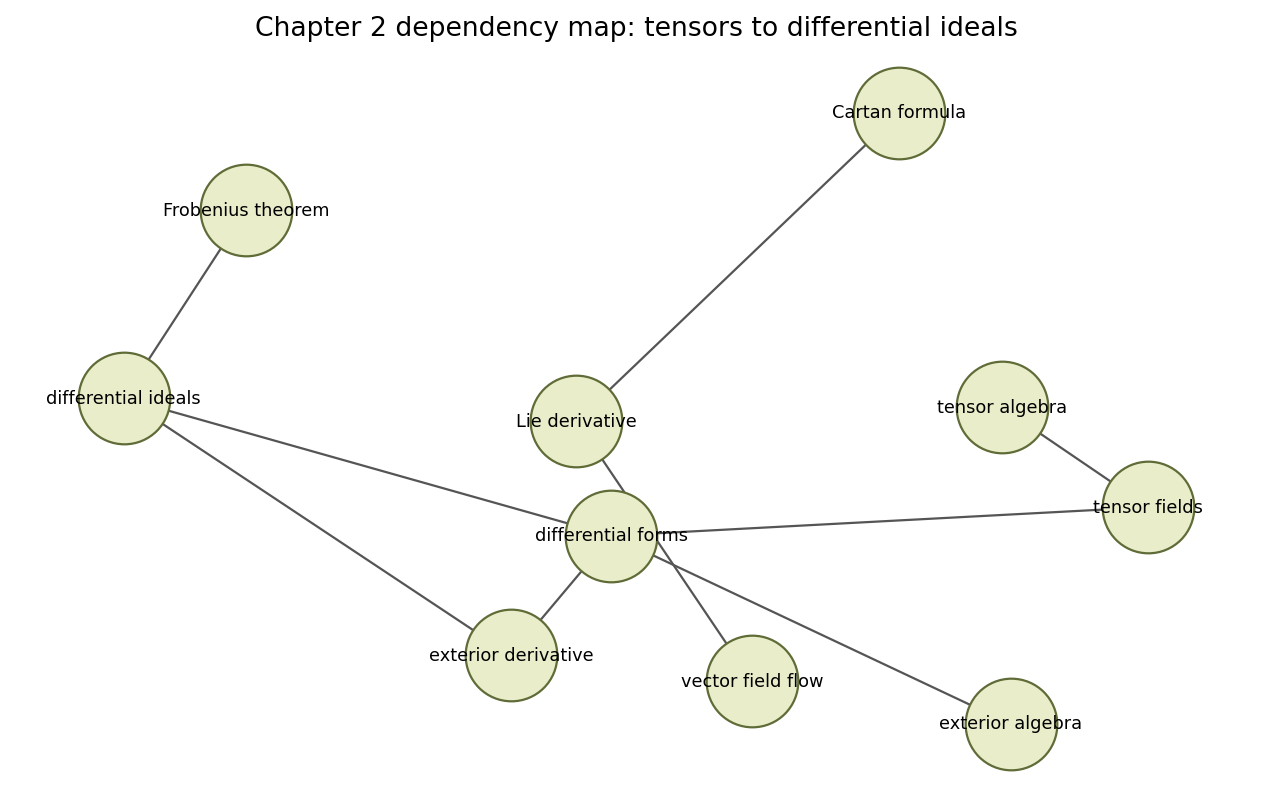

{'nodes': 10, 'edges': 9}

In [5]:
G=nx.DiGraph(); edges=[('tensor algebra','tensor fields'),('tensor fields','differential forms'),('exterior algebra','differential forms'),('differential forms','exterior derivative'),('vector field flow','Lie derivative'),('Lie derivative','Cartan formula'),('differential forms','differential ideals'),('differential ideals','Frobenius theorem'),('exterior derivative','differential ideals')]
G.add_edges_from(edges); pos=nx.spring_layout(G,seed=202,k=.85)
fig,ax=plt.subplots(figsize=(10,6)); nx.draw_networkx_edges(G,pos,ax=ax,arrows=True,arrowstyle='-|>',edge_color='#555'); nx.draw_networkx_nodes(G,pos,ax=ax,node_color='#e9edc9',edgecolors='#606c38',node_size=1700); nx.draw_networkx_labels(G,pos,ax=ax,font_size=8); ax.axis('off'); ax.set_title('Chapter 2 dependency map: tensors to differential ideals')
dep_path=save_matplotlib(fig, FIGURES/'tensors-forms-ideals-dependency-map.png'); plt.close(fig)
dep_json=save_json({'nodes':list(G.nodes),'edges':edges,'acyclic':nx.is_directed_acyclic_graph(G)}, CHECKS/'tensors-forms-ideals-dependency-map.json')
TRACKED_ARTIFACTS.extend([dep_path,dep_json]); display_artifact(dep_path,width=780)
{'nodes':G.number_of_nodes(),'edges':G.number_of_edges()}


In [6]:
assert slot_check and det_check
assert lie_check
assert integrable_obs == 0 and contact_obs != 0
assert nx.has_path(G,'tensor algebra','differential ideals')
assert_artifacts(TRACKED_ARTIFACTS,min_bytes=80)
final_sanity={'unit':UNIT_KEY,'tracked_artifacts':len(TRACKED_ARTIFACTS),'core_checks':['tensor slots','wedge determinant','Lie derivative flow','differential ideal obstruction','proof DAG']}
final_sanity


{'unit': 'chapter-02-tensors-and-differential-forms',
 'tracked_artifacts': 8,
 'core_checks': ['tensor slots',
  'wedge determinant',
  'Lie derivative flow',
  'differential ideal obstruction',
  'proof DAG']}

## Takeaways

Tensors give the multilinear language of tangent and cotangent spaces. Exterior forms are the alternating tensors that later support integration and cohomology. The Lie derivative differentiates this geometric data along a flow, and differential ideals encode when form-defined distributions are closed under exterior differentiation. Chapter 2 therefore supplies the algebraic machinery for Frobenius, Lie groups, integration, and de Rham theory.
